In [1]:
!pip install kumoai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.4/404.4 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.4/95.4 kB 7.3 MB/s eta 0:00:00


In [2]:
!gcloud auth application-default login

Go to the following link in your browser, and complete the sign-in prompts:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=764086051850-6qr4p6gpi6hn506pt8ejuq83di341hur.apps.googleusercontent.com&redirect_uri=https%3A%2F%2Fsdk.cloud.google.com%2Fapplicationdefaultauthcode.html&scope=openid+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fsqlservice.login&state=Bvsbhc0DlD5WUA720UgoqG8DppASqS&prompt=consent&token_usage=remote&access_type=offline&code_challenge=2Ua6R1GKFE1kF-M03PZO4vdws5_vR1sqALGu0wRAGpk&code_challenge_method=S256

Once finished, enter the verification code provided in your browser: 4/0AdkVLPzsT9T18Nak1NMReOpCMrZDes2n-VeOZ6rEqot4lLenjuIFUDmCG0Z6mbaplj-3lg

Credentials saved to file: [/content/.config/application_default_credentials.json]

These credentials will be used by any library that requests Application Default Credentials (ADC).
Ca

In [3]:
import os
import kumoai.experimental.rfm as rfm, os
import pandas as pd

from google.cloud import bigquery

In [5]:
KUMO_API_KEY = os.environ.get("KUMO_API_KEY")
rfm.init(api_key=KUMO_API_KEY)

INFO:kumoai:Initialized Kumo SDK v2.22.0 against deployment 'https://kumorfm.ai/api'


In [33]:
client = bigquery.Client(project="diesel-charge-465712-f8")

print("Fetching complete datasets from BigQuery...")

def get_data(query, anchor_name, anchor):
  return client.query(
    query,
    job_config=bigquery.QueryJobConfig(
        query_parameters=[bigquery.ArrayQueryParameter(anchor_name, "INT64", anchor)]
    )
  ).to_dataframe()

patient_ids = client.query("select patientunitstayid from `physionet-data.eicu_crd.patient` where rand() < 0.05").to_dataframe()['patientunitstayid'].tolist()
patient_df = get_data("select * from `physionet-data.eicu_crd.patient` where patientunitstayid in unnest(@patient_ids)", 'patient_ids', patient_ids)
medication_df = get_data("select * from `physionet-data.eicu_crd.medication` where patientunitstayid in unnest(@patient_ids)", 'patient_ids', patient_ids)
infusiondrug_df = get_data("select * from `physionet-data.eicu_crd.infusiondrug` where patientunitstayid in unnest(@patient_ids)", 'patient_ids', patient_ids)
treatment_df = get_data("select * from `physionet-data.eicu_crd.treatment` where patientunitstayid in unnest(@patient_ids)", 'patient_ids', patient_ids)
lab_df = get_data("select * from `physionet-data.eicu_crd.lab` where patientunitstayid in unnest(@patient_ids)", 'patient_ids', patient_ids)
vitalperiodic_df = get_data("select * from `physionet-data.eicu_crd.vitalperiodic` where patientunitstayid in unnest(@patient_ids)", 'patient_ids', patient_ids)
vital_aperiodic_df = get_data("select * from `physionet-data.eicu_crd.vitalaperiodic` where patientunitstayid in unnest(@patient_ids)", 'patient_ids', patient_ids)
admissiondx_df = get_data("select * from `physionet-data.eicu_crd.admissiondx` where patientunitstayid in unnest(@patient_ids)", 'patient_ids', patient_ids)
diagnosis_df = get_data("select * from `physionet-data.eicu_crd.diagnosis` where patientunitstayid in unnest(@patient_ids)", 'patient_ids', patient_ids)

/usr/local/lib/python3.12/dist-packages/google/auth/_default.py:114: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


Fetching complete datasets from BigQuery...


In [34]:
len(medication_df) + len(patient_df) + len(infusiondrug_df) + len(treatment_df) + len(lab_df) + len(vitalperiodic_df) + len(vital_aperiodic_df) + len(admissiondx_df) + len(diagnosis_df)

11543467

In [64]:
tables_dict = {
    'patient': patient_df,
    'medication': medication_df,
    'infusiondrug': infusiondrug_df,
    'treatment': treatment_df,
    'lab': lab_df,
    'vitalperiodic': vitalperiodic_df,
    'vital_aperiodic': vital_aperiodic_df,
    'admissiondx': admissiondx_df,
    'diagnosis': diagnosis_df
}

In [65]:
def preprocess_tables_dict(tables_dict):
    for table_name, df in tables_dict.items():
      dbdate_columns = df.dtypes[df.dtypes == 'dbdate'].index.tolist()
      dbtime_columns = df.dtypes[df.dtypes == 'dbtime'].index.tolist()
      for col in dbdate_columns:
        df[col] = pd.to_datetime(df[col])

      for col in dbtime_columns:
        df[col] = pd.to_datetime(df[col], format='%H:%M:%S').dt.time

    return tables_dict

In [66]:
def transform_to_rfm_table(tables_dict):
  result = {}
  for table_name, df in tables_dict.items():
    rfm_table = rfm.LocalTable(
      df = df,
      name = table_name
    ).infer_metadata()
    result[table_name] = rfm_table
  return result

In [67]:
tables_dict = preprocess_tables_dict(tables_dict)

In [68]:
tables = transform_to_rfm_table(tables_dict)

Inferred primary key `medicationid` for table `medication`

Inferred primary key `infusiondrugid` for table `infusiondrug`

Inferred primary key `treatmentid` for table `treatment`

Inferred primary key `vitalperiodicid` for table `vitalperiodic`

Inferred primary key `vitalaperiodicid` for table `vital_aperiodic`

Inferred primary key `admissiondxid` for table `admissiondx`

Inferred primary key `diagnosisid` for table `diagnosis`

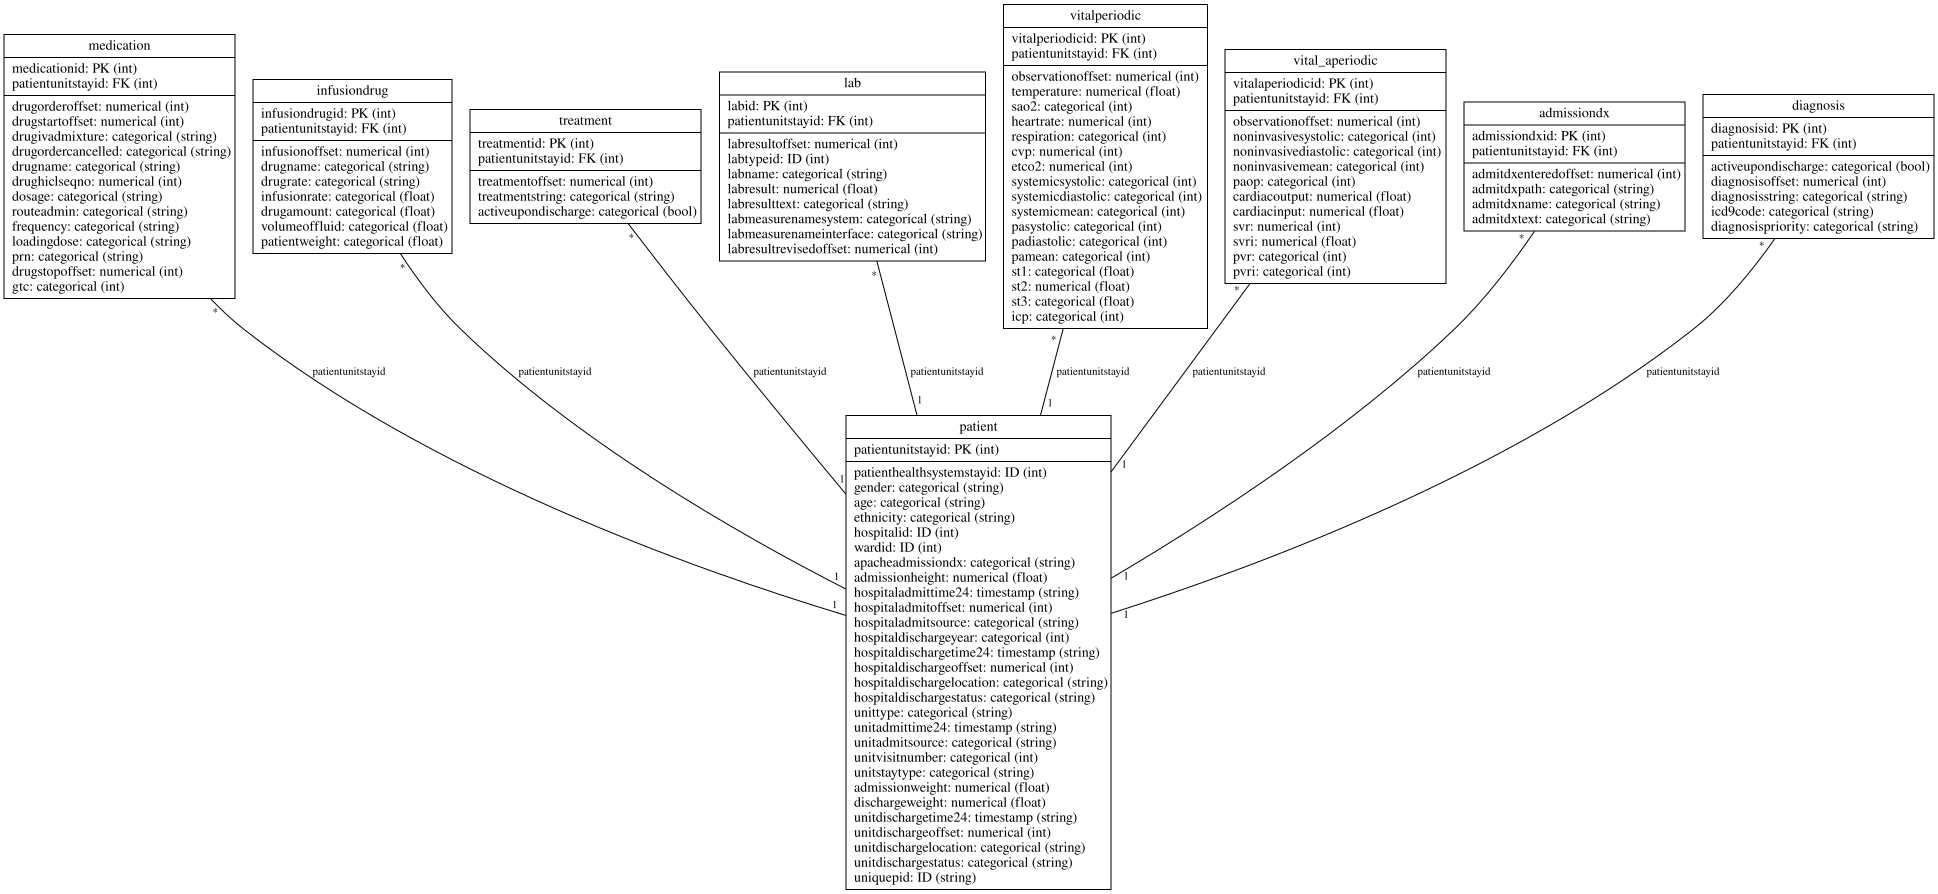

In [71]:
graph = rfm.LocalGraph(tables=tables.values())

tables['patient'].primary_key = "patientunitstayid"
tables['lab'].primary_key = "labid"

graph.link(src_table='medication', fkey='patientunitstayid', dst_table='patient')

graph.link(src_table='infusiondrug', fkey='patientunitstayid', dst_table='patient')

graph.link(src_table='treatment', fkey='patientunitstayid', dst_table='patient')

graph.link(src_table='lab', fkey='patientunitstayid', dst_table='patient')

graph.link(src_table='vitalperiodic', fkey='patientunitstayid', dst_table='patient')

graph.link(src_table='vital_aperiodic', fkey='patientunitstayid', dst_table='patient')

graph.link(src_table='admissiondx', fkey='patientunitstayid', dst_table='patient')

graph.link(src_table='diagnosis', fkey='patientunitstayid', dst_table='patient')

graph.visualize()

In [72]:
model = rfm.KumoRFM(graph=graph)

Output()

In [80]:
query = """
PREDICT patient.unitdischargelocation FOR EACH patient.patientunitstayid
"""

patient_ids = tables_dict['patient']['patientunitstayid'].dropna().astype(int).tolist()

with model.batch_mode(batch_size="max", num_retries=1):
    try:
        df = model.predict(query, indices=patient_ids)
        display(df.head())
    except Exception as e:
        print(f"Error: {e}")

Output()

,ENTITY,ANCHOR_TIMESTAMP,CLASS,SCORE,PREDICTED
0,374931,2262-04-11 23:47:16.709,Home,0.471360,True
1,374931,2262-04-11 23:47:16.709,Floor,0.205520,False
2,374931,2262-04-11 23:47:16.709,Other ICU,0.099189,False
3,374931,2262-04-11 23:47:16.709,Step-Down Unit (SDU),0.060752,False
4,374931,2262-04-11 23:47:16.709,Other Hospital,0.039532,False


In [82]:
metrics = model.evaluate(
    query,
    metrics=['acc',]
)

metrics

Output()

,metric,value
0,acc,0.5785


In [107]:
query = """
PREDICT vitalperiodic.systemicdiastolic < 50 FOR EACH vitalperiodic.vitalperiodicid
"""

patient_ids = tables_dict['vitalperiodic']['vitalperiodicid'].dropna().head(1000).astype(int).tolist()

with model.batch_mode(batch_size="max", num_retries=1):
    try:
        df = model.predict(query, indices=patient_ids)
        display(df.head())
    except Exception as e:
        print(f"Error: {e}")

/usr/local/lib/python3.12/dist-packages/kumoai/rfm/rfm.py:1264: UserWarning: Encountered the following warnings during parsing:
1. Semantic Type Mismatch: row 2, column 8: Expression vitalperiodic.systemicdiastolic has semantic type categorical. But you are comparing it by value with operator <. Consider changing the underlying semantic type to fit the task better.
  warnings.warn(f"Encountered the following warnings during "


Output()

,ENTITY,ANCHOR_TIMESTAMP,TARGET_PRED,False_PROB,True_PROB
0,42743673,2262-04-11 23:47:16.709,False,0.828939,0.171061
1,2068753670,2262-04-11 23:47:16.709,False,0.809276,0.190724
2,525699773,2262-04-11 23:47:16.709,False,0.762070,0.237930
3,1197427068,2262-04-11 23:47:16.709,False,0.798187,0.201813
4,1024766177,2262-04-11 23:47:16.709,False,0.752013,0.247987


In [111]:
metrics = model.evaluate(
    query,
    metrics=['acc', 'precision', 'recall', 'f1']
)

metrics

Output()

/usr/local/lib/python3.12/dist-packages/kumoai/rfm/rfm.py:1264: UserWarning: Encountered the following warnings during parsing:
1. Semantic Type Mismatch: row 2, column 8: Expression vitalperiodic.systemicdiastolic has semantic type categorical. But you are comparing it by value with operator <. Consider changing the underlying semantic type to fit the task better.
  warnings.warn(f"Encountered the following warnings during "


,metric,value
0,acc,0.854000
1,f1,0.640394
2,precision,0.734463
3,recall,0.567686


In [112]:
query = """
PREDICT lab.labresult > 4.0 FOR EACH lab.labid
"""

patient_ids = tables_dict['lab']['labid'].dropna().head(1000).astype(int).tolist()

with model.batch_mode(batch_size="max", num_retries=1):
    try:
        df = model.predict(query, indices=patient_ids)
        display(df.head())
    except Exception as e:
        print(f"Error: {e}")

Output()

,ENTITY,ANCHOR_TIMESTAMP,TARGET_PRED,False_PROB,True_PROB
0,770144900,2262-04-11 23:47:16.709,True,0.048677,0.951323
1,771796436,2262-04-11 23:47:16.709,True,0.070049,0.929951
2,769366144,2262-04-11 23:47:16.709,True,0.053206,0.946794
3,647971369,2262-04-11 23:47:16.709,True,0.073963,0.926037
4,647993625,2262-04-11 23:47:16.709,True,0.132066,0.867934


In [113]:
metrics = model.evaluate(
    query,
    metrics=['acc', 'precision', 'recall', 'f1']
)

metrics

Output()

,metric,value
0,acc,0.939000
1,f1,0.961756
2,precision,0.971501
3,recall,0.952204


In [114]:
query = """
PREDICT lab.labresult FOR EACH lab.labid
"""

patient_ids = tables_dict['lab']['labid'].dropna().head(1000).astype(int).tolist()

with model.batch_mode(batch_size="max", num_retries=1):
    try:
        df = model.predict(query, indices=patient_ids)
        display(df.head())
    except Exception as e:
        print(f"Error: {e}")

Output()

,ENTITY,ANCHOR_TIMESTAMP,TARGET_PRED
0,770144900,2262-04-11 23:47:16.709,11.834349
1,771796436,2262-04-11 23:47:16.709,9.835929
2,769366144,2262-04-11 23:47:16.709,12.000000
3,647971369,2262-04-11 23:47:16.709,102.000000
4,647993625,2262-04-11 23:47:16.709,87.000000


In [115]:
metrics = model.evaluate(
    query,
    metrics=['mae', 'mape', 'mse', 'rmse', 'smape', 'r2']
)

metrics

Output()

,metric,value
0,mae,26.772390
1,mape,7363.448242
2,mse,124582.468750
3,r2,0.028541
4,rmse,352.962433
5,smape,0.398678
